In [20]:
%pip install pandas numpy torch nltk scikit-learn matplotlib better_profanity seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import re
from typing import List, Callable, Optional
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from better_profanity import profanity
import matplotlib.pyplot as plt
import warnings

# Download NLTK resources (run once)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
warnings.filterwarnings("ignore")

Classical NLP Pipeline: Tokenization → TF-IDF → Classification

**Goal**: Predict review **sentiment** from text

In [2]:
df = pd.read_csv("IMDB_Dataset.csv")
df['sentiment'] = df['sentiment'].apply(lambda x: int(x == 'positive'))
df = df.loc[df[df['sentiment'] == 1].sample(2500, random_state=42).index.union(
           df[df['sentiment'] == 0].sample(2500, random_state=42).index)]
df.head()

,review,sentiment
33,One of the most significant quotes from the en...,1
35,"I bought this film at Blockbuster for $3.00, b...",0
56,The Hills Have Eyes II is what you would expec...,0
57,I laughed all the way through this rotten movi...,0
62,So let's begin!)))<br /><br />The movie itself...,1


In [3]:
print(f"Dataset size: {len(df)} reviews")
print(df.describe())
print(f"Positive: {df['sentiment'].sum()}, Negative: {len(df) - df['sentiment'].sum()}")

Dataset size: 5000 reviews
        sentiment
count  5000.00000
mean      0.50000
std       0.50005
min       0.00000
25%       0.00000
50%       0.50000
75%       1.00000
max       1.00000
Positive: 2500, Negative: 2500


In [4]:
def tokenize_regex(text: str) -> List[str]:
    pattern = r"""
        (?:[A-Z]\.)+                     # Acronyms like U.S.A.
        |\b\d+(?:\.\d+)?%?               # Numbers and percentages
        |\b\w+(?:[-']\w+)*\b             # Words with apostrophes and hyphens
        |[!?,.;:()\[\]{}]                # Punctuation
        |\.{3}                           # Ellipsis
        |\b(?:[+-]?\d+(?:\.\d+)?)\b      # Decimal numbers
        |\b(?:[0-9]+(?:st|nd|rd|th))\b   # Ordinal numbers
        |\b(?:[A-Z][a-z]+(?:-[A-Z][a-z]+)*)\b  # Proper nouns/capitalized phrases
    """
    return re.findall(pattern, text, re.VERBOSE)

def tokenize_nltk(text: str) -> List[str]:
    return word_tokenize(text)

STOP_WORDS = set(stopwords.words('english'))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()

def make_preprocessor(
    tokenizer: str = 'regex',
    lowercase: bool = True,
    remove_stopwords: bool = False,
    stem_or_lemma: Optional[str] = None,
) -> Callable[[str], str]:
    token_fn = tokenize_regex if tokenizer == 'regex' else tokenize_nltk

    def preprocess(text: str) -> str:
        tokens = token_fn(str(text))
        if lowercase:
            tokens = [t.lower() for t in tokens]
        if remove_stopwords:
            tokens = [t for t in tokens if t.lower() not in STOP_WORDS]
        if stem_or_lemma == 'stem':
            tokens = [STEMMER.stem(t) for t in tokens]
        elif stem_or_lemma == 'lemma':
            tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
        return ' '.join(tokens)
    return preprocess

In [5]:
PREPROCESS_CONFIGS = [
    {'name': 'Regex + lower',           'tokenizer': 'regex', 'lowercase': True,  'remove_stopwords': False, 'stem_or_lemma': None},
    {'name': 'Regex + lower + stop',    'tokenizer': 'regex', 'lowercase': True,  'remove_stopwords': True,  'stem_or_lemma': None},
    {'name': 'Regex + lower + stem',    'tokenizer': 'regex', 'lowercase': True,  'remove_stopwords': False, 'stem_or_lemma': 'stem'},
    {'name': 'Regex + lower + lemma',   'tokenizer': 'regex', 'lowercase': True,  'remove_stopwords': False, 'stem_or_lemma': 'lemma'},
    {'name': 'NLTK + lower',            'tokenizer': 'nltk',  'lowercase': True,  'remove_stopwords': False, 'stem_or_lemma': None},
    {'name': 'NLTK + lower + stop',     'tokenizer': 'nltk',  'lowercase': True,  'remove_stopwords': True,  'stem_or_lemma': None},
    {'name': 'NLTK + lower + stem',     'tokenizer': 'nltk',  'lowercase': True,  'remove_stopwords': False, 'stem_or_lemma': 'stem'},
]

In [6]:
X = df['review'].values
y = df['sentiment'].values
scv = StratifiedKFold(n_splits = 5, random_state = 42, shuffle = True)

## Pipeline: TF-IDF → Logistic Regression / MLP; LSTM on sequences

For each preprocessing config, we:
1. Preprocess texts
2. Fit TF-IDF on train → Logistic Regression and MLP
3. Evaluate on test set (accuracy, F1-macro)

Separately, an LSTM runs on token sequences with the best config.

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.8, random_state = 42)

majority_label = int(np.bincount(np.asarray(y_tr, dtype=int)).argmax())
y_pred_majority = np.full(shape=np.asarray(y_te).shape, fill_value=majority_label)

# For majority baseline, use constant probability for ROC/PR curves
majority_prob = np.full_like(y_te, fill_value=majority_label, dtype=float)

majority_acc = accuracy_score(y_te, y_pred_majority)
majority_f1 = f1_score(y_te, y_pred_majority, average='macro')
majority_roc_auc = roc_auc_score(y_te, majority_prob)
majority_pr_auc = average_precision_score(y_te, majority_prob)
majority_fpr, majority_tpr, _ = roc_curve(y_te, majority_prob)
majority_precision, majority_recall, _ = precision_recall_curve(y_te, majority_prob)

accuracies = {'lr': [], 'mlp': []}
f1s = {'lr': [], 'mlp': []}
rocs_aucs = {'lr': [], 'mlp': []}
pr_aucs = {'lr': [], 'mlp': []}
fprs = {'lr': [], 'mlp': []}
tprs = {'lr': [], 'mlp': []}
precisions = {'lr': [], 'mlp': []}
recalls = {'lr': [], 'mlp': []}

for train_index, test_index in scv.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    tfidf_uni = TfidfVectorizer(
        max_features=5000,
        min_df=2,
        ngram_range=(1, 1),
        tokenizer=lambda s: str(s).lower().split(),
    )
    X_train_uni_vec = tfidf_uni.fit_transform(X_train)
    X_test_uni_vec = tfidf_uni.transform(X_test)

    lr_uni = LogisticRegression(max_iter=500, random_state=42).fit(X_train_uni_vec, y_train)
    lr_uni_pred = lr_uni.predict(X_test_uni_vec)
    lr_uni_pred_proba = lr_uni.predict_proba(X_test_uni_vec)[:, 1]
    lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_uni_pred_proba)
    lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_uni_pred_proba)

    mlp_uni = MLPClassifier(max_iter = 300, 
                            hidden_layer_sizes = (128, 64, 32), 
                            activation = 'tanh', 
                            alpha = 0.0001,
                            random_state = 42)
    mlp_uni.fit(X_train_uni_vec, y_train)
    mlp_uni_pred = mlp_uni.predict(X_test_uni_vec)
    mlp_uni_pred_proba = mlp_uni.predict_proba(X_test_uni_vec)[:, 1]
    mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_uni_pred_proba)
    mlp_precision, mlp_recall, _ = precision_recall_curve(y_test, mlp_uni_pred_proba)
    
    accuracies['lr'].append(accuracy_score(y_test, lr_uni_pred))
    f1s['lr'].append(f1_score(y_test, lr_uni_pred, average='macro'))
    rocs_aucs['lr'].append(roc_auc_score(y_test, lr_uni_pred_proba))
    pr_aucs['lr'].append(average_precision_score(y_test, lr_uni_pred_proba))
    fprs['lr'].append(lr_fpr)
    tprs['lr'].append(lr_tpr)
    precisions['lr'].append(lr_precision)
    recalls['lr'].append(lr_recall)
    accuracies['mlp'].append(accuracy_score(y_test, mlp_uni_pred))
    f1s['mlp'].append(f1_score(y_test, mlp_uni_pred, average='macro'))
    rocs_aucs['mlp'].append(roc_auc_score(y_test, mlp_uni_pred_proba))
    pr_aucs['mlp'].append(average_precision_score(y_test, mlp_uni_pred_proba))
    fprs['mlp'].append(mlp_fpr)
    tprs['mlp'].append(mlp_tpr)
    precisions['mlp'].append(mlp_precision)
    recalls['mlp'].append(mlp_recall)

baseline_rows = pd.DataFrame([
    {
        'config': 'Majority baseline',
        'lr_acc_mean': majority_acc,
        'lr_acc_std': 0.0,
        'lr_f1_mean': majority_f1,
        'lr_f1_std': 0.0,
        'lr_ra_mean': majority_roc_auc,
        'lr_ra_std': 0.0,
        'lr_pr_auc': majority_pr_auc,
        'lr_fpr_mean': [majority_fpr],
        'lr_tpr_mean': [majority_tpr],
        'lr_precision_mean': [majority_precision],
        'lr_recall_mean': [majority_recall],
        'mlp_acc_mean': majority_acc,
        'mlp_acc_std': 0.0,
        'mlp_f1_mean': majority_f1,
        'mlp_f1_std': 0.0,
        'mlp_ra_mean': majority_roc_auc,
        'mlp_ra_std': 0.0,
        'mlp_pr_auc': majority_pr_auc,
        'mlp_fpr_mean': [majority_fpr],
        'mlp_tpr_mean': [majority_tpr],
        'mlp_precision_mean': [majority_precision],
        'mlp_recall_mean': [majority_recall],
    },
    {
        'config': 'Unigram TF-IDF',
        'lr_acc_mean': np.mean(accuracies['lr']),
        'lr_acc_std': np.std(accuracies['lr']),
        'lr_f1_mean': np.mean(f1s['lr']),
        'lr_f1_std': np.std(f1s['lr']),
        'lr_ra_mean': np.mean(rocs_aucs['lr']),
        'lr_ra_std': np.std(rocs_aucs['lr']),
        'lr_pr_auc': np.mean(pr_aucs['lr']),
        'lr_fpr_last': fprs['lr'][-1],
        'lr_tpr_last': tprs['lr'][-1],
        'lr_precision_last': precisions['lr'][-1],
        'lr_recall_last': recalls['lr'][-1],
        'mlp_acc_mean': np.mean(accuracies['mlp']),
        'mlp_acc_std': np.std(accuracies['mlp']),
        'mlp_f1_mean': np.mean(f1s['mlp']),
        'mlp_f1_std': np.std(f1s['mlp']),
        'mlp_ra_mean': np.mean(rocs_aucs['mlp']),
        'mlp_ra_std': np.std(rocs_aucs['mlp']),
        'mlp_pr_auc': np.mean(pr_aucs['mlp']),
        'mlp_fpr_last': fprs['mlp'][-1],
        'mlp_tpr_last': tprs['mlp'][-1],
        'mlp_precision_last': precisions['mlp'][-1],
        'mlp_recall_last': recalls['mlp'][-1],
    },
])

In [8]:
def run_pipeline(config: dict, X, y) -> dict:
    accuracies = {'lr': [], 'mlp': []}
    precisions = {'lr': [], 'mlp': []}
    recalls = {'lr': [], 'mlp': []}
    f1s = {'lr': [], 'mlp': []}
    rocs_aucs = {'lr': [], 'mlp': []}
    prs_aucs = {'lr': [], 'mlp': []}
    fpr = {'lr': [], 'mlp': []}
    tpr = {'lr': [], 'mlp': []}

    for train_index, test_index in scv.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        preprocess = make_preprocessor(**{k: config[k] for k in ['tokenizer', 'lowercase', 'remove_stopwords', 'stem_or_lemma']})
        X_train_pp = np.array([preprocess(x) for x in X_train])
        X_test_pp = np.array([preprocess(x) for x in X_test])

        tfidf = TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 2), tokenizer=lambda s: s.split())
        X_train_vec = tfidf.fit_transform(X_train_pp)
        X_test_vec = tfidf.transform(X_test_pp)

        lr = LogisticRegression(max_iter=500, random_state=42)
        lr.fit(X_train_vec, y_train)
        lr_pred = lr.predict(X_test_vec)
        lr_pred_proba = lr.predict_proba(X_test_vec)[:, 1]
        lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
        lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_pred_proba)

        mlp = MLPClassifier(max_iter = 300, 
                            hidden_layer_sizes = (128, 64, 32), 
                            activation = 'tanh', 
                            alpha = 0.0001,
                            random_state = 42)
        mlp.fit(X_train_vec, y_train)
        mlp_pred = mlp.predict(X_test_vec)
        mlp_pred_proba = mlp.predict_proba(X_test_vec)[:, 1]
        mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_pred_proba)
        mlp_precision, mlp_recall, _ = precision_recall_curve(y_test, mlp_pred_proba)

        accuracies['lr'].append(accuracy_score(y_test, lr_pred))
        accuracies['mlp'].append(accuracy_score(y_test, mlp_pred))
        f1s['lr'].append(f1_score(y_test, lr_pred, average='macro'))
        f1s['mlp'].append(f1_score(y_test, mlp_pred, average='macro'))
        rocs_aucs['lr'].append(roc_auc_score(y_test, lr_pred_proba))
        rocs_aucs['mlp'].append(roc_auc_score(y_test, mlp_pred_proba))
        prs_aucs['lr'].append(average_precision_score(y_test, lr_pred_proba))
        prs_aucs['mlp'].append(average_precision_score(y_test, mlp_pred_proba))
        precisions['lr'].append(lr_precision)
        precisions['mlp'].append(mlp_precision)
        recalls['lr'].append(lr_recall)
        recalls['mlp'].append(mlp_recall)
        fpr['lr'].append(lr_fpr)
        tpr['lr'].append(lr_tpr)
        fpr['mlp'].append(mlp_fpr)
        tpr['mlp'].append(mlp_tpr)

    return {
        'lr_acc_mean': np.mean(accuracies['lr']),
        'lr_acc_std': np.std(accuracies['lr']),
        'lr_f1_mean': np.mean(f1s['lr']),
        'lr_f1_std': np.std(f1s['lr']),
        'lr_ra_mean': np.mean(rocs_aucs['lr']),
        'lr_ra_std': np.std(rocs_aucs['lr']),
        'lr_pr_auc_mean': np.mean(prs_aucs['lr']),
        'lr_pr_auc_std': np.std(prs_aucs['lr']),
        'lr_fpr_last': fpr['lr'][-1],
        'lr_tpr_last': tpr['lr'][-1],
        'lr_precision_last': precisions['lr'][-1],
        'lr_recall_last': recalls['lr'][-1],
        'mlp_acc_mean': np.mean(accuracies['mlp']),
        'mlp_acc_std': np.std(accuracies['mlp']),
        'mlp_f1_mean': np.mean(f1s['mlp']),
        'mlp_f1_std': np.std(f1s['mlp']),
        'mlp_ra_mean': np.mean(rocs_aucs['mlp']),
        'mlp_ra_std': np.std(rocs_aucs['mlp']),
        'mlp_pr_auc_mean': np.mean(prs_aucs['mlp']),
        'mlp_pr_auc_std': np.std(prs_aucs['mlp']),
        'mlp_fpr_last': fpr['mlp'][-1],
        'mlp_tpr_last': tpr['mlp'][-1],
        'mlp_precision_last': precisions['mlp'][-1],
        'mlp_recall_last': recalls['mlp'][-1]
    }

In [9]:
results = []
for cfg in PREPROCESS_CONFIGS:
    result = run_pipeline(cfg, X, y)

    results.append({
        'config': cfg['name'],
        'lr_acc_mean': result['lr_acc_mean'],
        'lr_acc_std': result['lr_acc_std'],
        'lr_f1_mean': result['lr_f1_mean'],
        'lr_f1_std': result['lr_f1_std'],
        'lr_ra_mean': result['lr_ra_mean'],
        'lr_ra_std': result['lr_ra_std'],
        'lr_pr_auc_mean': result['lr_pr_auc_mean'],
        'lr_pr_auc_std': result['lr_pr_auc_std'],
        'lr_fpr_last': result['lr_fpr_last'],
        'lr_tpr_last': result['lr_tpr_last'],
        'lr_precision_last': result['lr_precision_last'],
        'lr_recall_last': result['lr_recall_last'],
        'mlp_acc_mean': result['mlp_acc_mean'],
        'mlp_acc_std': result['mlp_acc_std'],
        'mlp_f1_mean': result['mlp_f1_mean'],
        'mlp_f1_std': result['mlp_f1_std'],
        'mlp_ra_mean': result['mlp_ra_mean'],
        'mlp_ra_std': result['mlp_ra_std'],
        'mlp_pr_auc_mean': result['mlp_pr_auc_mean'],
        'mlp_pr_auc_std': result['mlp_pr_auc_std'],
        'mlp_fpr_last': result['mlp_fpr_last'],
        'mlp_tpr_last': result['mlp_tpr_last'],
        'mlp_precision_last': result['mlp_precision_last'],
        'mlp_recall_last': result['mlp_recall_last'],
    })

    print(f"{cfg['name']}: LR F1={results[-1]['lr_f1_mean']:.3f} ± {results[-1]['lr_f1_std']:.3f}, MLP F1={results[-1]['mlp_f1_mean']:.3f} ± {results[-1]['mlp_f1_std']:.3f}")
    print("----------------------")

Regex + lower: LR F1=0.856 ± 0.020, MLP F1=0.852 ± 0.013
----------------------
Regex + lower + stop: LR F1=0.865 ± 0.012, MLP F1=0.852 ± 0.014
----------------------
Regex + lower + stem: LR F1=0.858 ± 0.015, MLP F1=0.854 ± 0.013
----------------------
Regex + lower + lemma: LR F1=0.854 ± 0.014, MLP F1=0.849 ± 0.010
----------------------
NLTK + lower: LR F1=0.855 ± 0.020, MLP F1=0.847 ± 0.015
----------------------
NLTK + lower + stop: LR F1=0.859 ± 0.014, MLP F1=0.848 ± 0.013
----------------------
NLTK + lower + stem: LR F1=0.855 ± 0.012, MLP F1=0.852 ± 0.013
----------------------


In [ ]:
results_df = pd.DataFrame(results)
results_df = pd.concat([baseline_rows, results_df], ignore_index=True)
results_df.to_csv("sentiment_analysis_results.csv", index=False)
results_df

,config,lr_acc_mean,lr_acc_std,lr_f1_mean,lr_f1_std,lr_ra_mean,lr_ra_std,lr_pr_auc,lr_fpr_mean,lr_tpr_mean,...,lr_precision_last,lr_recall_last,mlp_fpr_last,mlp_tpr_last,mlp_precision_last,mlp_recall_last,lr_pr_auc_mean,lr_pr_auc_std,mlp_pr_auc_mean,mlp_pr_auc_std
0,Majority baseline,0.49875,0.000000,0.332777,0.000000,0.500000,0.000000,0.501250,"[[0.0, 1.0]]","[[0.0, 1.0]]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Unigram TF-IDF,0.84280,0.009948,0.842767,0.009948,0.921478,0.010155,0.921528,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.004, 0.004, 0....","[0.0, 0.002, 0.018, 0.018, 0.188, 0.188, 0.24,...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN,NaN,NaN,NaN
2,Regex + lower,0.85600,0.019524,0.855959,0.019508,0.931905,0.011540,NaN,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.004, 0.004, 0....","[0.0, 0.002, 0.016, 0.016, 0.156, 0.156, 0.284...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.932059,0.011034,0.929321,0.008128
3,Regex + lower + stop,0.86460,0.012027,0.864519,0.012036,0.937466,0.009620,NaN,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.004, 0.004, 0....","[0.0, 0.002, 0.026, 0.026, 0.208, 0.208, 0.342...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.936314,0.009848,0.927750,0.008184
4,Regex + lower + stem,0.85780,0.015224,0.857773,0.015224,0.936461,0.011168,NaN,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.004, 0.004, 0....","[0.0, 0.002, 0.006, 0.006, 0.116, 0.116, 0.326...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.937345,0.010168,0.934530,0.009545
5,Regex + lower + lemma,0.85440,0.014486,0.854361,0.014482,0.932042,0.011439,NaN,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.004, 0.004, 0....","[0.0, 0.002, 0.018, 0.018, 0.266, 0.266, 0.294...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.932403,0.011012,0.928817,0.009280
6,NLTK + lower,0.85480,0.019681,0.854766,0.019674,0.927764,0.012239,NaN,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.004, 0.004, 0....","[0.0, 0.002, 0.012, 0.012, 0.158, 0.158, 0.238...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.927975,0.012499,0.924163,0.009637
7,NLTK + lower + stop,0.85940,0.014151,0.859333,0.014206,0.932107,0.010201,NaN,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.002, 0.002, 0.004, 0.004, 0.006, 0.006...","[0.0, 0.0, 0.146, 0.146, 0.214, 0.214, 0.232, ...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.930407,0.011453,0.920359,0.011070
8,NLTK + lower + stem,0.85520,0.012352,0.855159,0.012344,0.932385,0.011455,NaN,NaN,NaN,...,"[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.004, 0.004, 0....","[0.0, 0.002, 0.008, 0.008, 0.086, 0.086, 0.212...","[0.5, 0.5005005005005005, 0.501002004008016, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.933317,0.011448,0.929166,0.009589


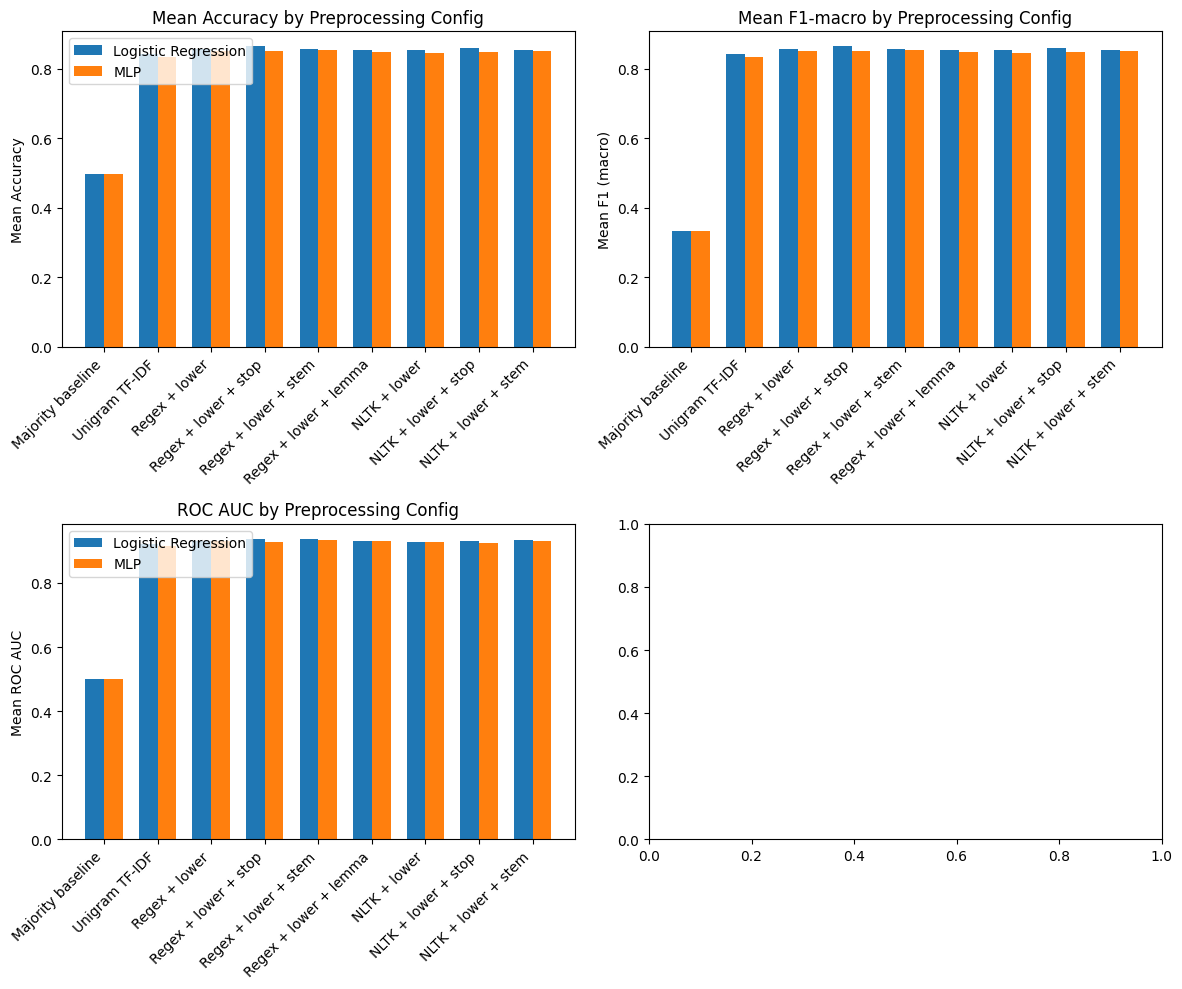

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

x = range(len(results_df))
w = 0.35
axes[0, 0].bar([i - w/2 for i in x], results_df['lr_acc_mean'], width=w, label='Logistic Regression')
axes[0, 0].bar([i + w/2 for i in x], results_df['mlp_acc_mean'], width=w, label='MLP')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(results_df['config'], rotation=45, ha='right')
axes[0, 0].set_ylabel('Mean Accuracy')
axes[0, 0].set_title('Mean Accuracy by Preprocessing Config')
axes[0, 0].legend()

axes[0, 1].bar([i - w/2 for i in x], results_df['lr_f1_mean'], width=w, label='Logistic Regression')
axes[0, 1].bar([i + w/2 for i in x], results_df['mlp_f1_mean'], width=w, label='MLP')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(results_df['config'], rotation=45, ha='right')
axes[0, 1].set_ylabel('Mean F1 (macro)')
axes[0, 1].set_title('Mean F1-macro by Preprocessing Config')
axes[1, 0].legend()

axes[1, 0].bar([i - w/2 for i in x], results_df['lr_ra_mean'], width=w, label='Logistic Regression')
axes[1, 0].bar([i + w/2 for i in x], results_df['mlp_ra_mean'], width=w, label='MLP')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(results_df['config'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Mean ROC AUC')
axes[1, 0].set_title('ROC AUC by Preprocessing Config')
axes[1, 0].legend()
plt.tight_layout()
plt.show()

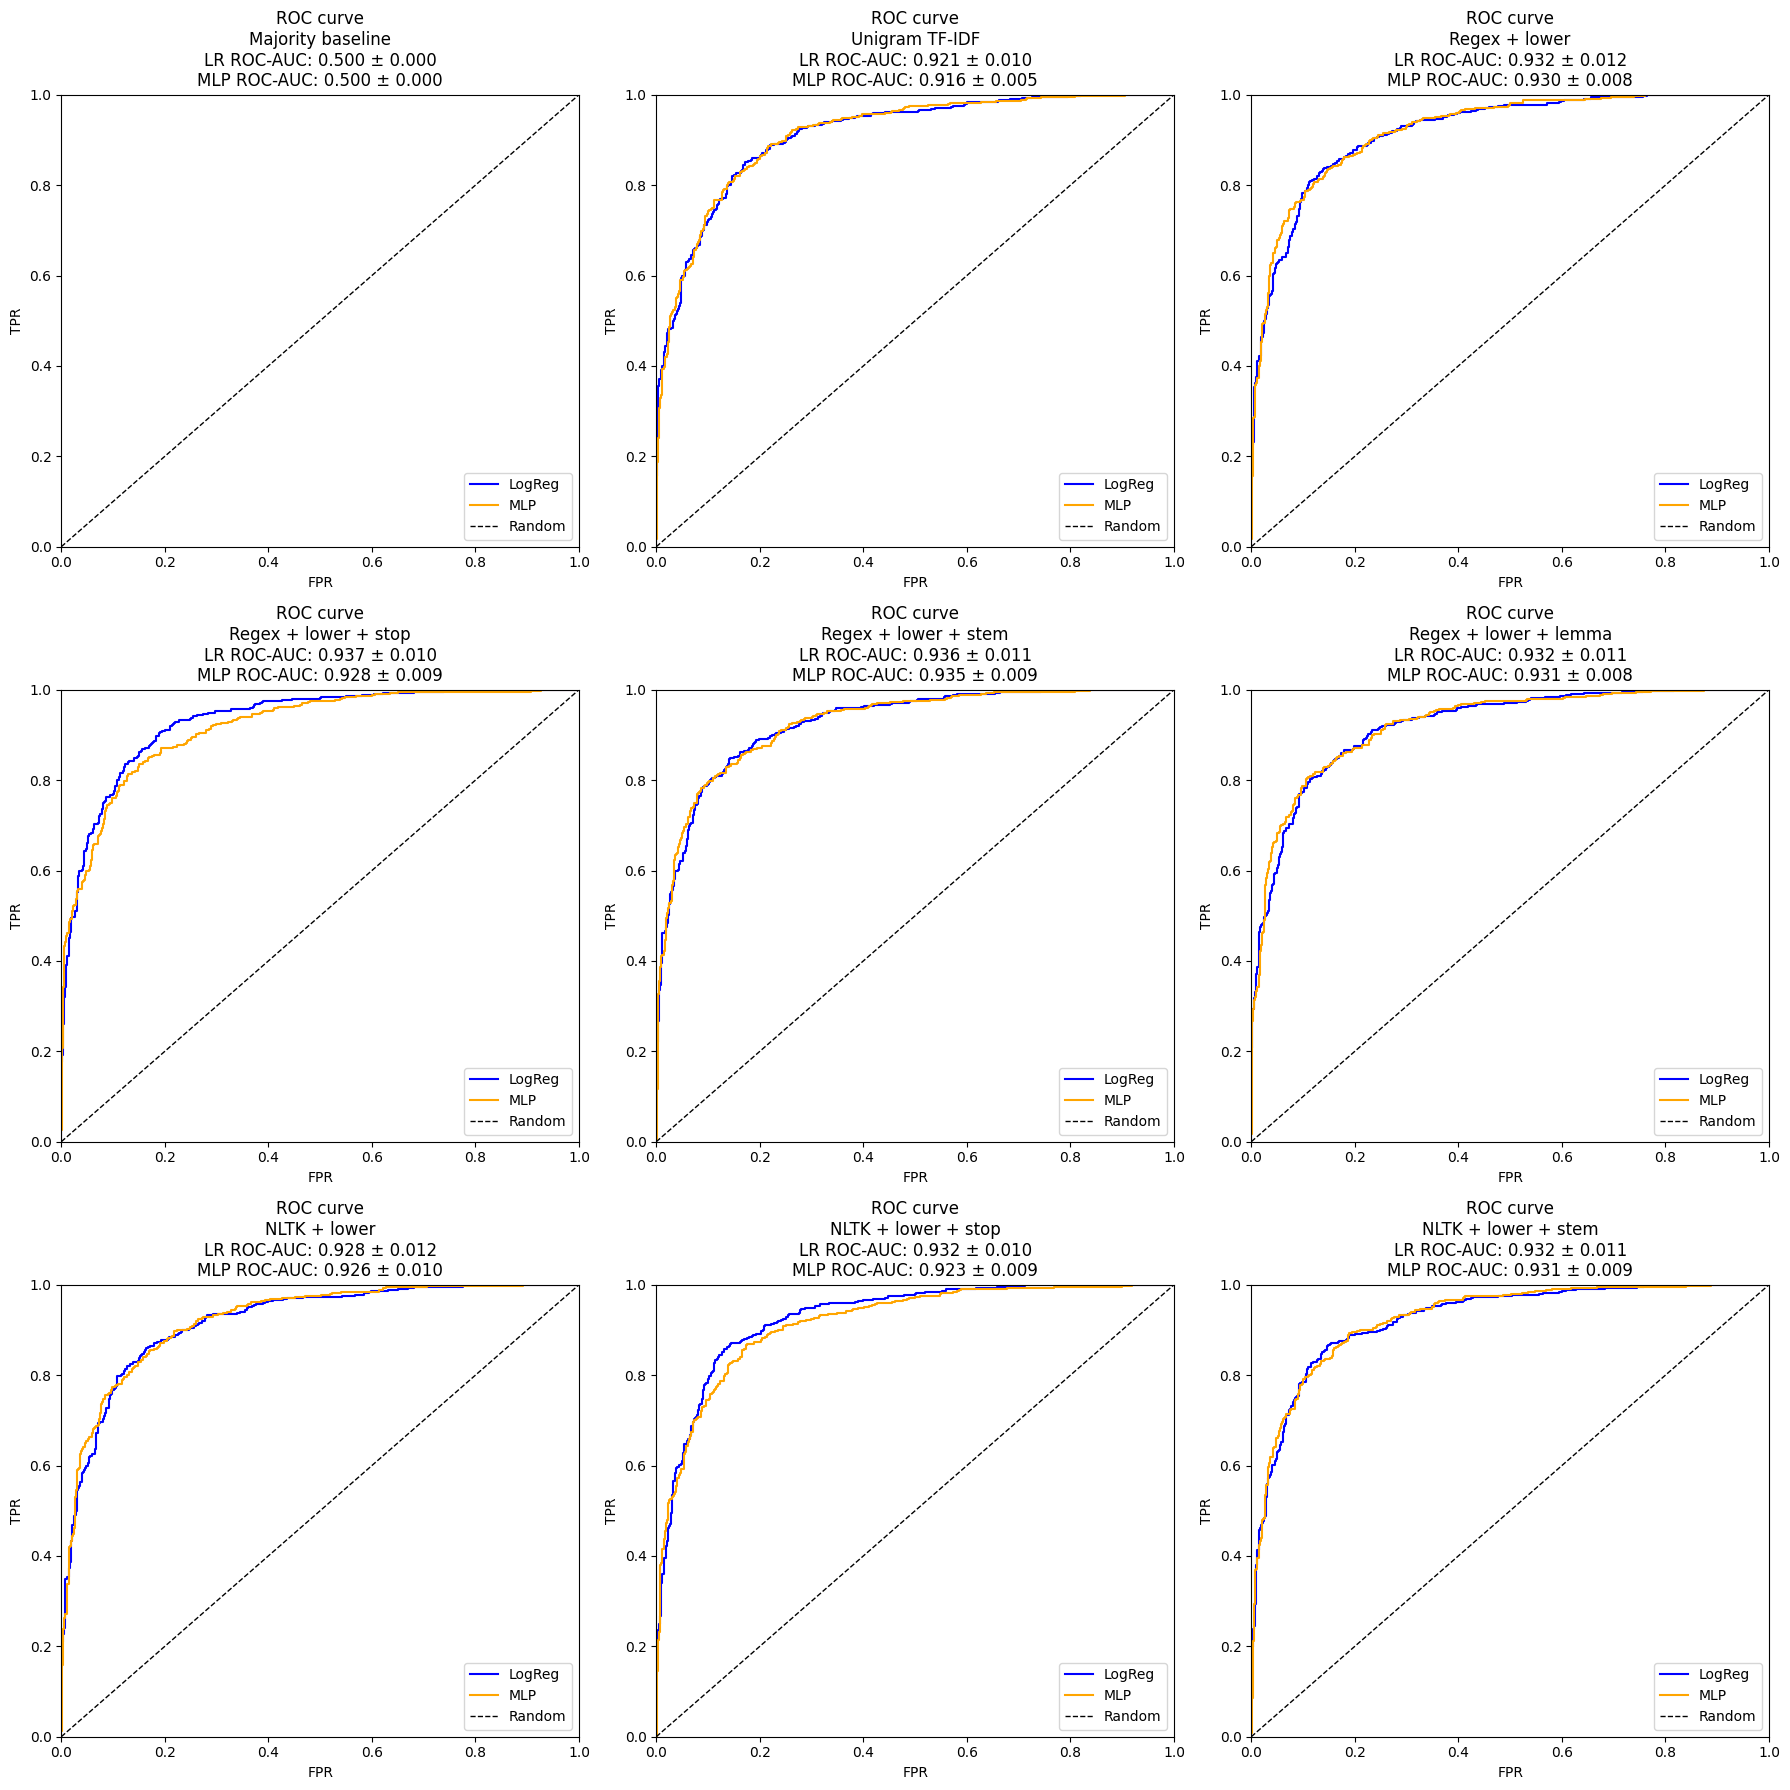

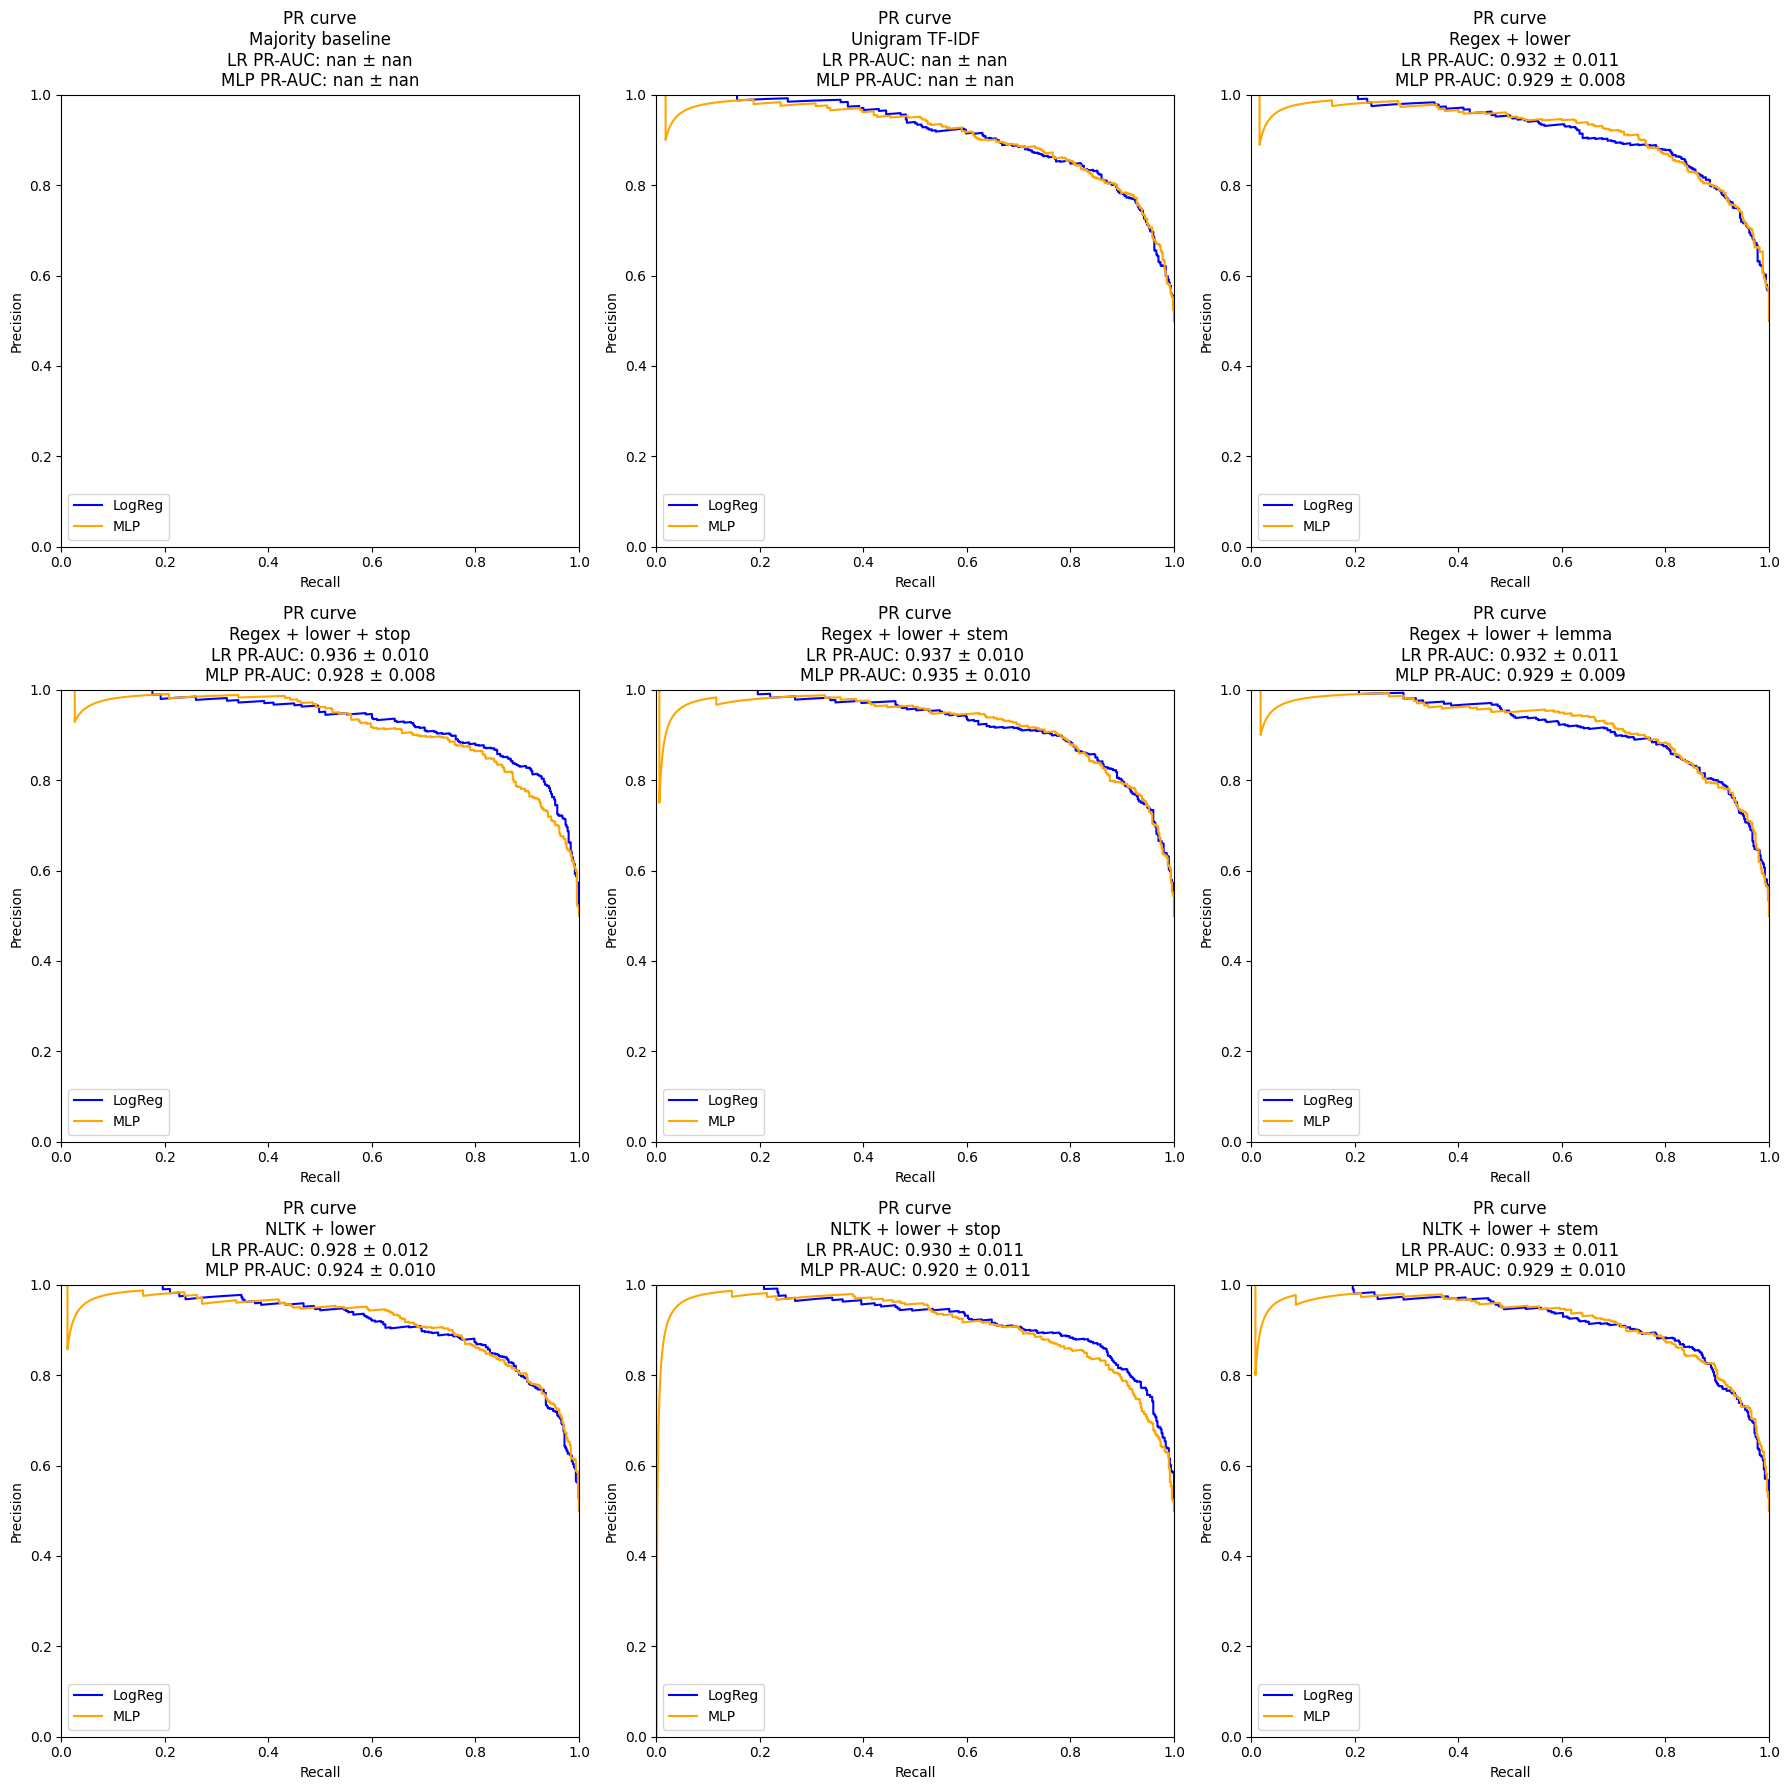

In [ ]:
configs_to_plot = results_df['config'].tolist()[:9] 
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for idx, config in enumerate(configs_to_plot):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    row_data = results_df[results_df['config'] == config].iloc[0]
    ax.plot(row_data['lr_fpr_last'], row_data['lr_tpr_last'], label='LogReg', color='blue')
    ax.plot(row_data['mlp_fpr_last'], row_data['mlp_tpr_last'], label='MLP', color='orange')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f'ROC curve\n{config}\nLR ROC-AUC: {row_data["lr_ra_mean"]:.3f} ± {row_data["lr_ra_std"]:.3f}\nMLP ROC-AUC: {row_data["mlp_ra_mean"]:.3f} ± {row_data["mlp_ra_std"]:.3f}')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(['LogReg', 'MLP', 'Random'], loc='lower right')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for idx, config in enumerate(configs_to_plot):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    row_data = results_df[results_df['config'] == config].iloc[0]
    ax.plot(row_data['lr_recall_last'], row_data['lr_precision_last'], label='LogReg', color='blue')
    ax.plot(row_data['mlp_recall_last'], row_data['mlp_precision_last'], label='MLP', color='orange')
    ax.set_title(f'PR curve\n{config}\nLR PR-AUC: {row_data["lr_pr_auc_mean"]:.3f} ± {row_data["lr_pr_auc_std"]:.3f}\nMLP PR-AUC: {row_data["mlp_pr_auc_mean"]:.3f} ± {row_data["mlp_pr_auc_std"]:.3f}')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(['LogReg', 'MLP'], loc='lower left')

plt.tight_layout()
plt.show()

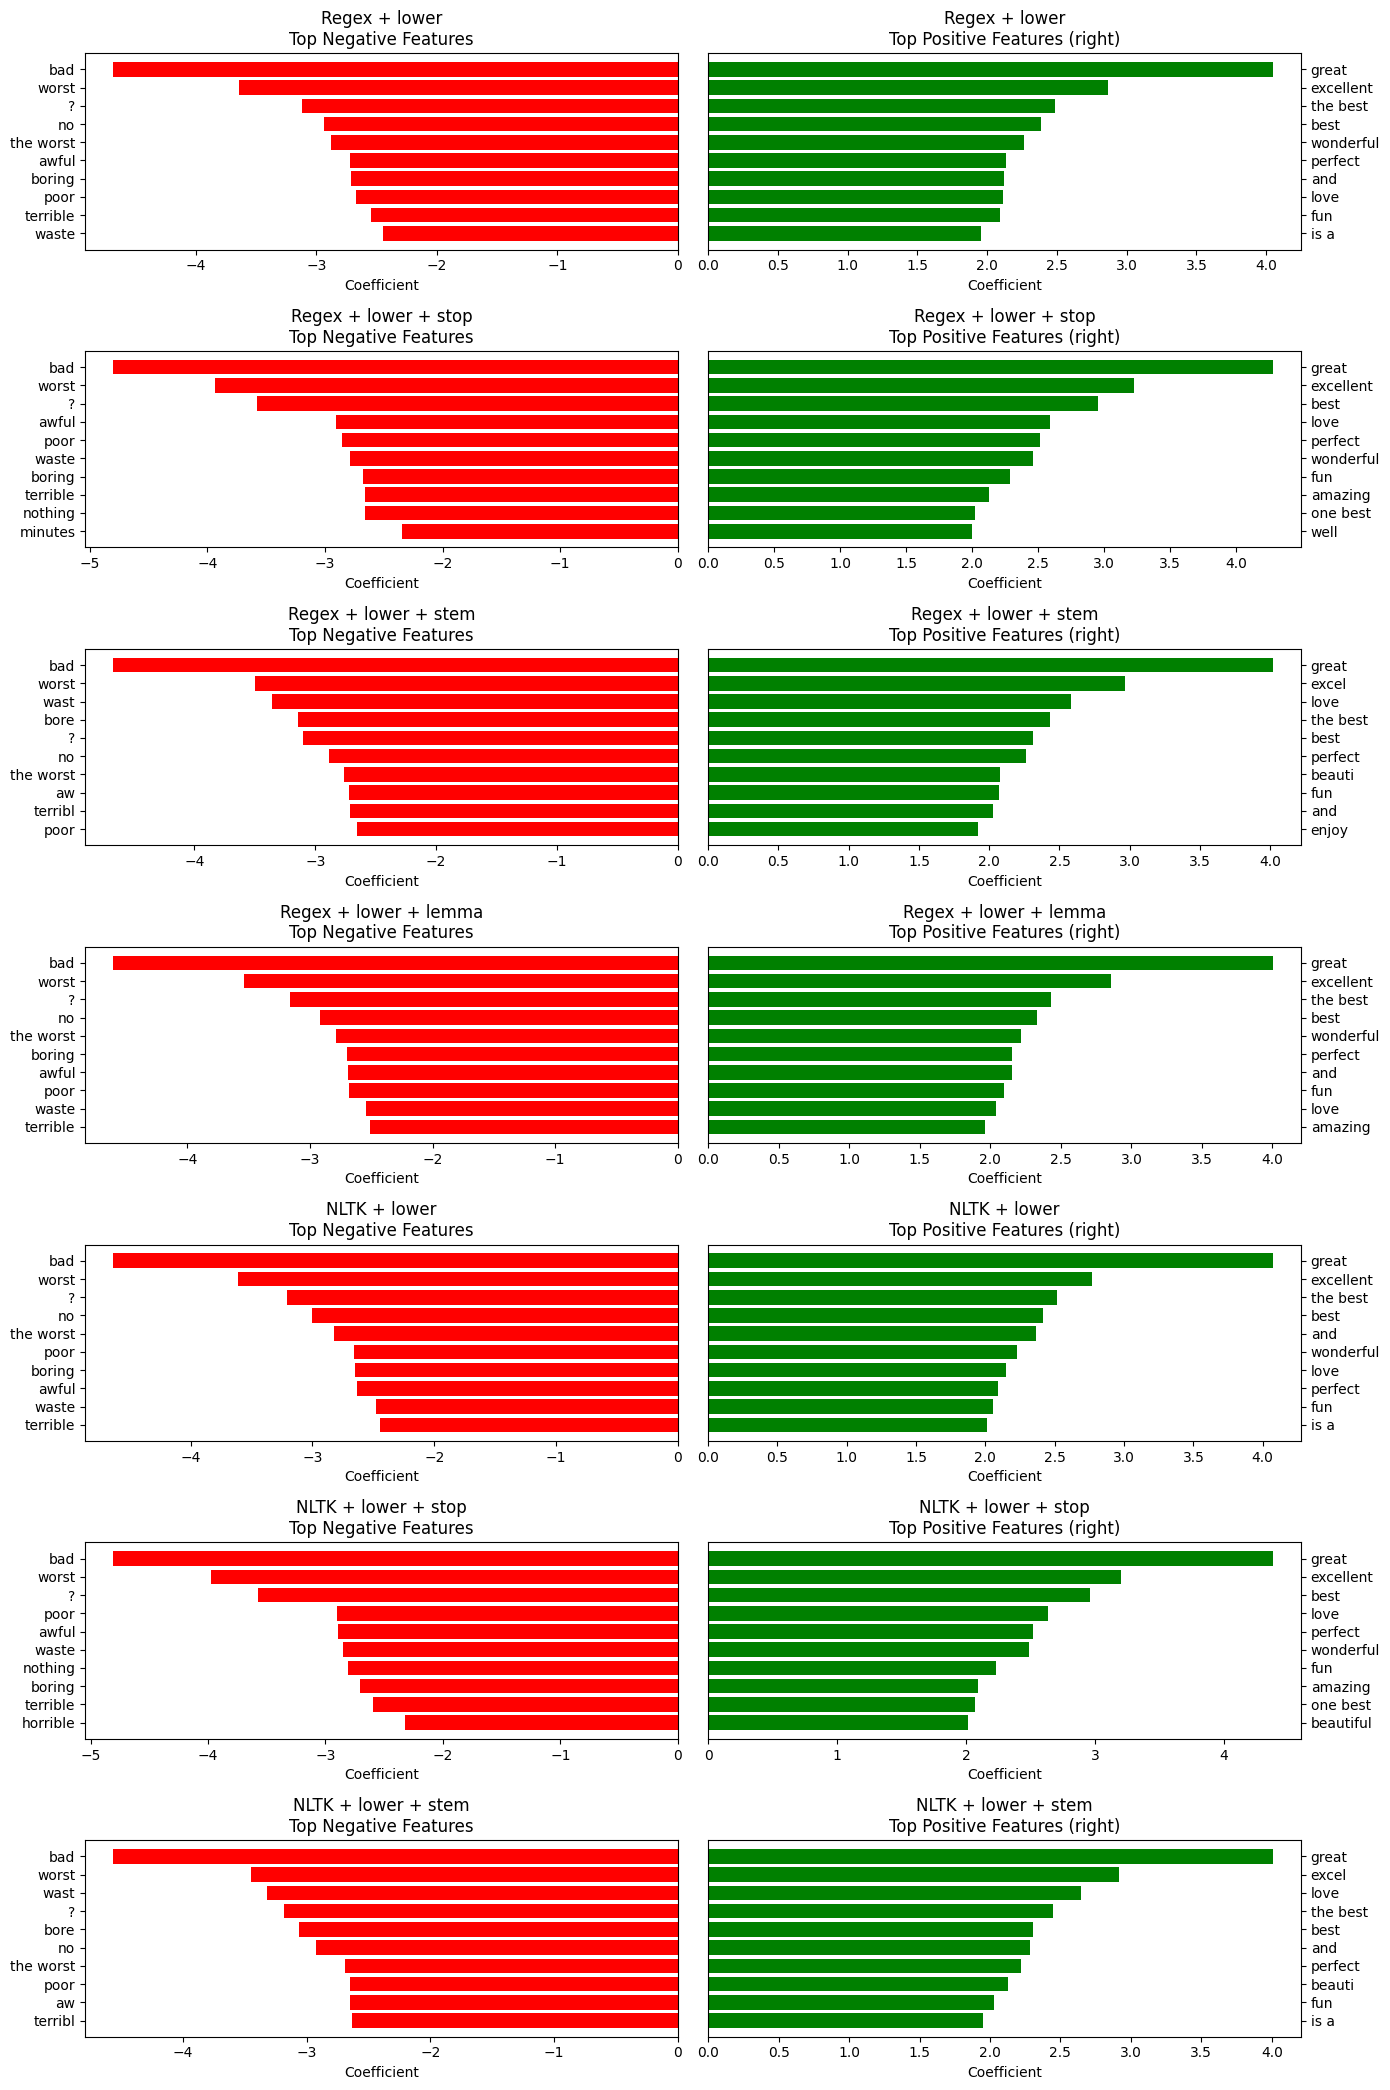

In [31]:
n_top = 10
num_configs = len(PREPROCESS_CONFIGS)
fig, axes = plt.subplots(num_configs, 2, figsize=(14, 3 * num_configs))

for i, config in enumerate(PREPROCESS_CONFIGS):
    preprocess = make_preprocessor(**{k: config[k] for k in ['tokenizer', 'lowercase', 'remove_stopwords', 'stem_or_lemma']})
    X_pp = np.array([preprocess(x) for x in X])
    tfidf = TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 2), tokenizer=lambda s: s.split())
    X_vec = tfidf.fit_transform(X_pp)
    lr = LogisticRegression(max_iter=500, random_state=42)
    lr.fit(X_vec, y)
    feature_names = np.array(tfidf.get_feature_names_out())
    coefs = lr.coef_[0]
    sorted_idx = np.argsort(coefs)
    top_negative = feature_names[sorted_idx[:n_top]]
    top_positive = feature_names[sorted_idx[-n_top:][::-1]]
    top_negative_coefs = coefs[sorted_idx[:n_top]]
    top_positive_coefs = coefs[sorted_idx[-n_top:][::-1]]
    ax_neg = axes[i, 0] if num_configs > 1 else axes[0]
    ax_neg.barh(top_negative[::-1], top_negative_coefs[::-1], color='red')
    ax_neg.set_title(f"{config['name']}\nTop Negative Features")
    ax_neg.set_xlabel('Coefficient')
    ax_pos = axes[i, 1] if num_configs > 1 else axes[1]
    ax_pos.barh(top_positive[::-1], top_positive_coefs[::-1], color='green')
    ax_pos.set_title(f"{config['name']}\nTop Positive Features (right)")
    ax_pos.set_xlabel('Coefficient')
    ax_pos.yaxis.set_label_position('right')
    ax_pos.yaxis.tick_right()
    
plt.tight_layout()
plt.show()